# PCB Defect Dataset Exploration

Explores the processed PCB defect crop dataset (`data/processed/`, split via
`data/splits/{train,val,test}.csv`) before any model training happens:
class balance, source-image/crop counts, raw image dimensions, and a look at
a handful of example crops per class.

Run `python -m src.preprocessing` from the repository root first if
`data/splits/manifest.csv` does not exist yet.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

sys.path.append(str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd()))
from src.utils import PROJECT_ROOT, CLASS_NAMES

pd.set_option("display.max_columns", None)
manifest = pd.read_csv(PROJECT_ROOT / "data" / "splits" / "manifest.csv")
manifest.head()

,crop_path,class_name,source_image,split
0,data/processed/missing_hole/01_missing_hole_01...,missing_hole,data/raw/images/Missing_hole/01_missing_hole_0...,val
1,data/processed/missing_hole/01_missing_hole_01...,missing_hole,data/raw/images/Missing_hole/01_missing_hole_0...,val
2,data/processed/missing_hole/01_missing_hole_01...,missing_hole,data/raw/images/Missing_hole/01_missing_hole_0...,val
3,data/processed/missing_hole/01_missing_hole_02...,missing_hole,data/raw/images/Missing_hole/01_missing_hole_0...,train
4,data/processed/missing_hole/01_missing_hole_02...,missing_hole,data/raw/images/Missing_hole/01_missing_hole_0...,train


## Crops per class and per split

In [2]:
counts = manifest.groupby(["class_name", "split"]).size().unstack(fill_value=0)
counts["total"] = counts.sum(axis=1)
counts.loc["total"] = counts.sum()
counts

split,test,train,val,total
class_name,,,,
missing_hole,73,352,72,497
open_circuit,67,342,73,482
short,75,340,76,491
spur,70,342,76,488
total,285,1376,297,1958


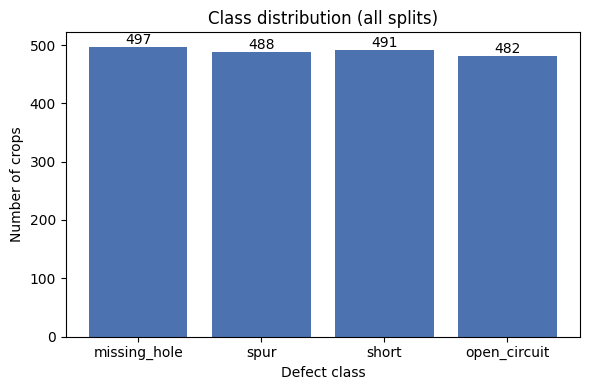

Most/least represented class ratio: 1.03x


In [3]:
class_totals = manifest.groupby("class_name").size().reindex(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(class_totals.index, class_totals.values, color="#4C72B0")
ax.set_ylabel("Number of crops")
ax.set_title("Class distribution (all splits)")
ax.set_xlabel("Defect class")
for i, v in enumerate(class_totals.values):
    ax.text(i, v + 5, str(v), ha="center")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "outputs" / "plots" / "class_distribution.png", dpi=150)
plt.show()

imbalance_ratio = class_totals.max() / class_totals.min()
print(f"Most/least represented class ratio: {imbalance_ratio:.2f}x")

The four classes are close to balanced (each defect class comes from roughly
the same number of source PCB boards, and boards tend to contain a similar
number of annotated defects), so no class-weighting or resampling was judged
necessary for the baseline experiments.

## How many source boards contribute crops to each split

In [4]:
source_counts = (
    manifest.drop_duplicates(["source_image", "split"])
    .groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
)
source_counts

split,test,train,val
class_name,,,
missing_hole,17,81,17
open_circuit,17,82,17
short,17,82,17
spur,17,81,17


This confirms the split happened at the *source board* level: every
`source_image` appears in exactly one of train/val/test, so crops from the
same board never leak across splits (see `src/preprocessing.py` for the
splitting logic and rationale).

## Raw image dimensions (before cropping)

In [5]:
raw_images_dir = PROJECT_ROOT / "data" / "raw" / "images"
sample_paths = sorted(raw_images_dir.glob("*/*.jpg"))[:60]
dims = []
for p in sample_paths:
    with Image.open(p) as im:
        dims.append(im.size)
dims = np.array(dims)
pd.DataFrame(dims, columns=["width", "height"]).describe()

,width,height
count,60.000000,60.000000
mean,2932.000000,2095.333333
std,186.946924,378.006666
min,2544.000000,1586.000000
25%,2868.000000,1586.000000
50%,3034.000000,2236.000000
75%,3056.000000,2464.000000
max,3056.000000,2464.000000


Raw PCB photographs are large and vary in size (multiple megapixels), which
is exactly why `src/preprocessing.py` crops out each annotated defect region
and resizes every crop to a fixed 128x128 before it reaches the model,
rather than resizing whole boards.

## Processed crop dimensions (sanity check)

In [6]:
processed_sample = manifest.sample(min(200, len(manifest)), random_state=42)
sizes = set()
for rel_path in processed_sample["crop_path"]:
    with Image.open(PROJECT_ROOT / rel_path) as im:
        sizes.add(im.size)
print("Distinct processed crop sizes found:", sizes)

Distinct processed crop sizes found: {(128, 128)}


## Example crops

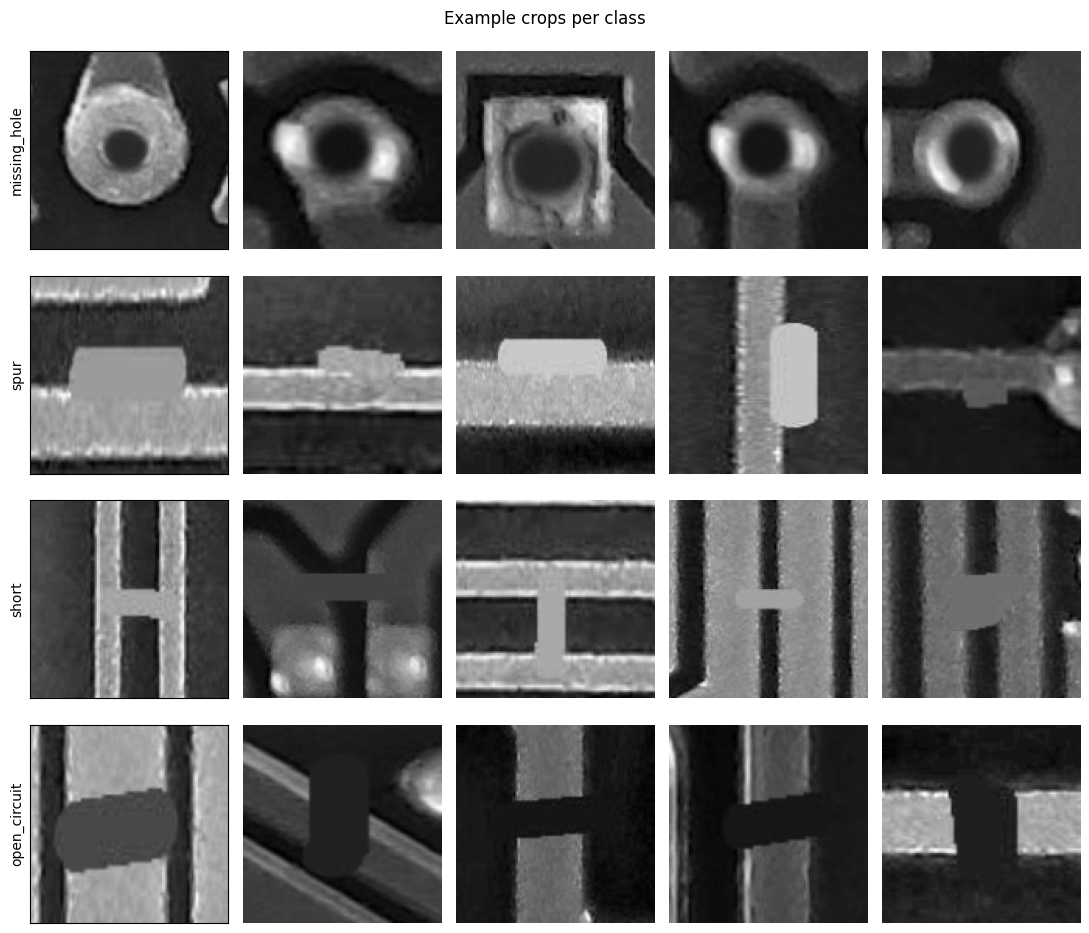

In [7]:
rng = np.random.default_rng(7)
fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(11, 2.4 * len(CLASS_NAMES)))
for row, class_name in enumerate(CLASS_NAMES):
    class_rows = manifest[manifest["class_name"] == class_name]
    sample = class_rows.sample(5, random_state=int(rng.integers(0, 10_000)))
    for col, (_, r) in enumerate(sample.iterrows()):
        img = Image.open(PROJECT_ROOT / r["crop_path"])
        ax = axes[row, col]
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(class_name)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(class_name, fontsize=10)
fig.suptitle("Example crops per class")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "outputs" / "plots" / "example_crops.png", dpi=150)
plt.show()